In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import altair as alt
import ipywidgets as widgets
from IPython.display import display, clear_output

climate_df = pd.read_csv('climate_data.csv')
stock_price_df = pd.read_csv('daily_stock_price.csv')
firm_info_df = pd.read_csv('firm_info.csv')

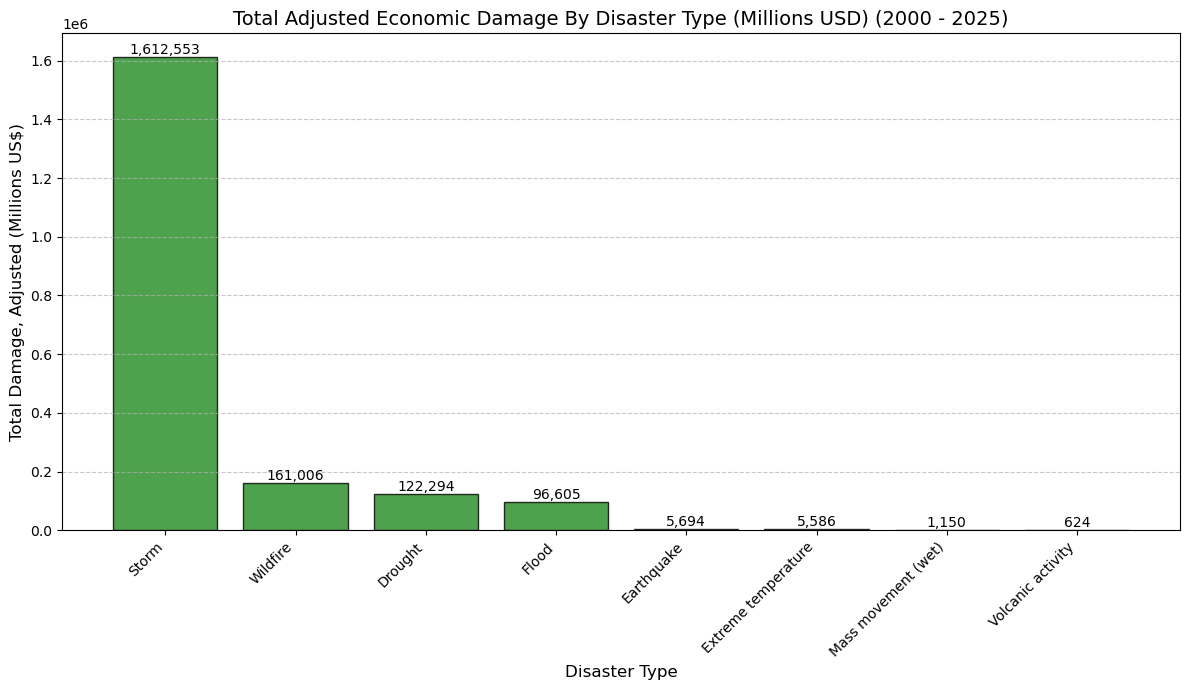

In [2]:
damage_by_type = (
    climate_df.groupby('Disaster Type')["Total Damage, Adjusted ('000 US$)"]
        .sum()
        .sort_values(ascending = False)
        .reset_index()
)

damage_by_type['Damage_Millions'] = damage_by_type["Total Damage, Adjusted ('000 US$)"] / 1000

plt.figure(figsize = (12, 7))
bars = plt.bar(damage_by_type['Disaster Type'], damage_by_type["Damage_Millions"], color = 'forestgreen', edgecolor = 'black', alpha = 0.8)

plt.title('Total Adjusted Economic Damage By Disaster Type (Millions USD) (2000 - 2025)', fontsize = 14)
plt.ylabel("Total Damage, Adjusted (Millions US$)", fontsize = 12)
plt.xlabel('Disaster Type', fontsize = 12)
plt.xticks(rotation = 45, ha = 'right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', va = 'bottom', ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

In [3]:
storms_df = climate_df[climate_df['Disaster Type'] == 'Storm'].copy()

cols_to_show = ['Event Name', 'Start Year', "Total Damage, Adjusted ('000 US$)"]
ranked_storms = storms_df[cols_to_show].copy()

ranked_storms['Damage (Millions USD)'] = ranked_storms["Total Damage, Adjusted ('000 US$)"] / 1000

ranked_storms = ranked_storms.sort_values(by = 'Damage (Millions USD)', ascending = False)

final_list = ranked_storms.drop(columns = ["Total Damage, Adjusted ('000 US$)"])

print("Top 5 Most Damaging Storms (Millions USD):")
print(final_list.head(5))


Top 5 Most Damaging Storms (Millions USD):
               Event Name  Start Year  Damage (Millions USD)
603               Katrina        2005             200782.317
216      Hurricane Harvey        2017             121575.099
333       Hurricane 'Ian'        2022             107187.331
108  Tropical storm 'Ida'        2021              75247.457
317      Hurricane 'Irma'        2017              72945.059


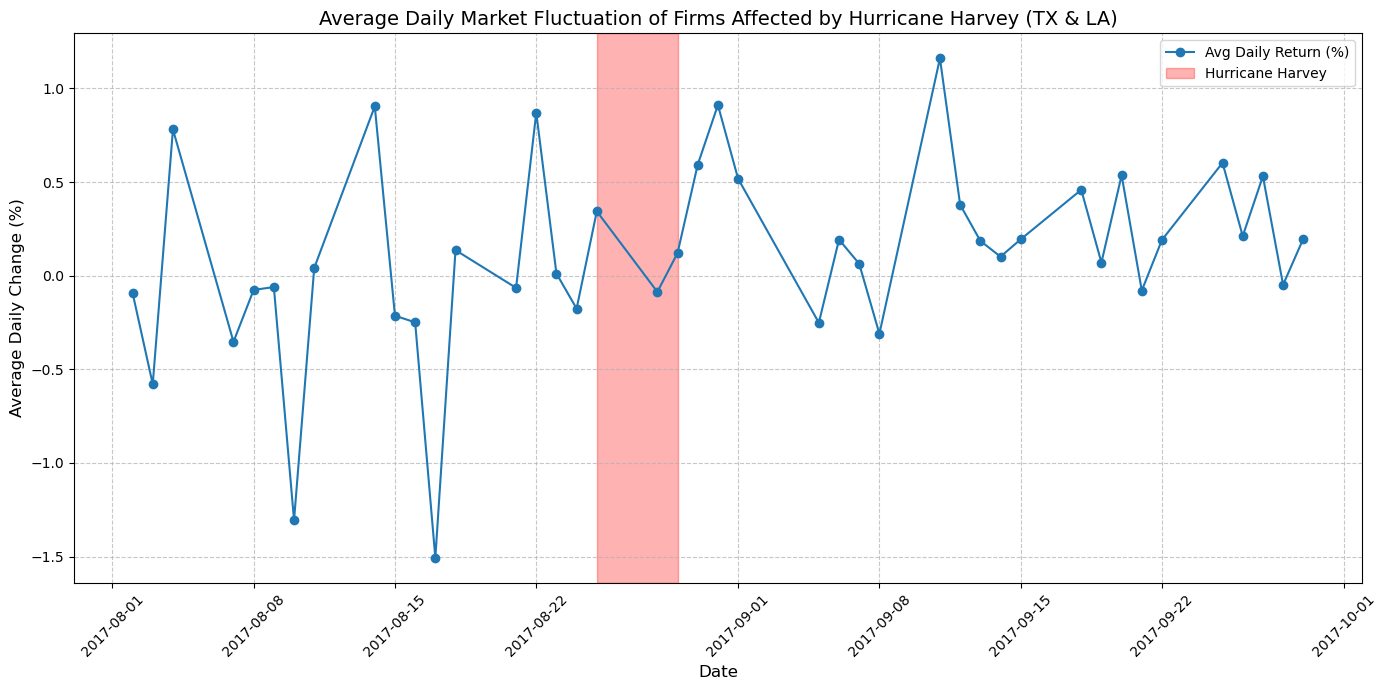

In [4]:
firm_info_df['State'] = firm_info_df['Headquarters Location'].str.split(',').str[-1].str.strip()
harvey_symbols = firm_info_df[firm_info_df['State'].isin(['Texas', 'Louisiana'])]['Symbol'].tolist()
valid_symbols = [s for s in harvey_symbols if s in stock_price_df.columns]

stock_price_df['Date'] = pd.to_datetime(stock_price_df['Date'])
mask = (stock_price_df['Date'] >= '2017-08-01') & (stock_price_df['Date'] <= '2017-09-30')
window_df = stock_price_df.loc[mask, ['Date'] + valid_symbols].copy().sort_values('Date')

for s in valid_symbols:
    window_df[f'{s}_pct'] = window_df[s].ffill().pct_change(fill_method = None) * 100

pct_cols = [f'{s}_pct' for s in valid_symbols]
window_df['Avg_Fluctuation'] = window_df[pct_cols].mean(axis=1)

plt.figure(figsize=(14, 7))
plt.plot(window_df['Date'], window_df['Avg_Fluctuation'], marker='o', linestyle='-', color='tab:blue', label='Avg Daily Return (%)')

plt.axvspan(pd.to_datetime('2017-08-25'), pd.to_datetime('2017-08-29'), color='red', alpha=0.3, label='Hurricane Harvey')

plt.title('Average Daily Market Fluctuation of Firms Affected by Hurricane Harvey (TX & LA)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Daily Change (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
company_options = sorted([(firm_info_df[firm_info_df['Symbol'] == s]['Security'].iloc[0], s) for s in valid_symbols])

indiv_dropdown = widgets.Dropdown(
    options=company_options,
    description='Select Firm:',
    style={'description_width': 'initial'}
)
indiv_output = widgets.Output()

def update_indiv_plot(change):
    symbol = change['new']
    harvey_start = pd.to_datetime('2017-08-25')
    harvey_end = pd.to_datetime('2017-08-29')

    window_days = 10
    start_date = harvey_start - pd.Timedelta(days = window_days)
    end_date = harvey_end + pd.Timedelta(days = window_days)
    
    plot_df = window_df[(window_df['Date'] >= start_date) & (window_df['Date'] <= end_date)].copy()
    
    with indiv_output:
        clear_output(wait=True)
        
        plt.figure(figsize=(12, 5))
        
        plt.plot(plot_df['Date'], plot_df['Avg_Fluctuation'], 
                 color='gray', alpha=0.3, label='TX/LA Group Avg %')
        
        plt.plot(plot_df['Date'], plot_df[f'{symbol}_pct'], 
                 marker='o', color='forestgreen', linewidth=2, label=f'{symbol} Daily Return')

        plt.axhline(0, color='black', linewidth=1, alpha=0.5)
        plt.axvspan(harvey_start, harvey_end, color='red', alpha=0.1, label='Harvey Duration')
        
        plt.title(f"Individual Market Fluctuation: {symbol}", fontsize=14, fontweight='bold')
        plt.ylabel("Daily Change (%)")
        plt.xlabel("Date")
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.xticks(rotation=45)
        
        # Ensure the x-axis strictly shows our 20-day window
        plt.xlim(start_date, end_date)
        
        plt.tight_layout()
        plt.show()

indiv_dropdown.observe(update_indiv_plot, names='value')
print("\n--- Individual Firm Analysis ---")
display(indiv_dropdown)
display(indiv_output)

update_indiv_plot({'new': indiv_dropdown.value})


--- Individual Firm Analysis ---


Dropdown(description='Select Firm:', options=(('APA Corporation', 'APA'), ('AT&T', 'T'), ('Atmos Energy', 'ATO…

Output()

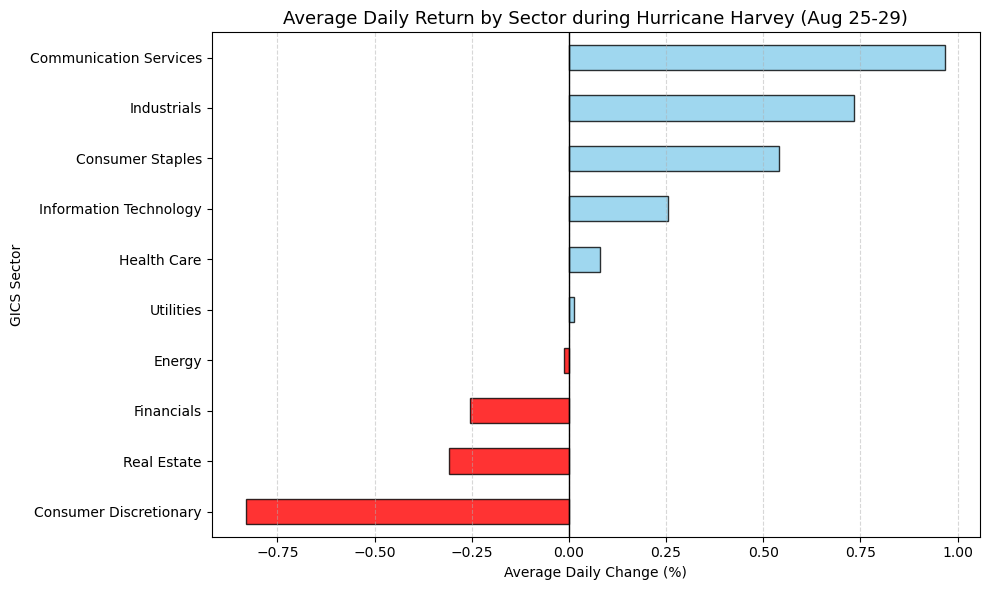

In [6]:
sector_map = firm_info_df[firm_info_df['Symbol'].isin(valid_symbols)][['Symbol', 'GICS Sector']]

peak_days = window_df[(window_df['Date'] >= '2017-08-25') & (window_df['Date'] <= '2017-08-29')]
symbol_avg_returns = peak_days[[  f'{s}_pct' for s in valid_symbols]].mean().reset_index()
symbol_avg_returns.columns = ['Symbol_pct', 'Avg_Return']
symbol_avg_returns['Symbol'] = symbol_avg_returns['Symbol_pct'].str.replace('_pct', '')

sector_impact = symbol_avg_returns.merge(sector_map, on='Symbol')
sector_summary = sector_impact.groupby('GICS Sector')['Avg_Return'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'skyblue' for x in sector_summary]
sector_summary.plot(kind='barh', color=colors, edgecolor='black', alpha=0.8)

plt.title('Average Daily Return by Sector during Hurricane Harvey (Aug 25-29)', fontsize=13)
plt.xlabel('Average Daily Change (%)')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()